# Spaceship-Titanic


In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 


from sklearn import svm, tree, linear_model, neighbors, naive_bayes, ensemble, discriminant_analysis, gaussian_process
from xgboost import XGBClassifier


from sklearn.ensemble import VotingClassifier
from sklearn import model_selection
from sklearn.model_selection import GridSearchCV 
from sklearn.model_selection import RandomizedSearchCV 

## Preparing datasets

In [3]:
data_train = pd.read_csv('data/train.csv')
data_test = pd.read_csv('data/test.csv')

data_train["train_test"] = True
data_test["train_test"] = False
data_test["Transported"] = np.nan

data_merged = pd.concat([data_train, data_test], axis=0, ignore_index=True)

In [4]:
print(data_train.columns)

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported', 'train_test'],
      dtype='object')


In [5]:
print(data_train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
 14  train_test    8693 non-null   bool   
dtypes: bool(2), float64(6), object(7)
memory usage: 900.0+ KB
None


In [6]:
print("Null values per column in train: \n", data_train.isnull().sum())

Null values per column in train: 
 PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
train_test        0
dtype: int64


In [7]:
print(data_test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   4277 non-null   object 
 1   HomePlanet    4190 non-null   object 
 2   CryoSleep     4184 non-null   object 
 3   Cabin         4177 non-null   object 
 4   Destination   4185 non-null   object 
 5   Age           4186 non-null   float64
 6   VIP           4184 non-null   object 
 7   RoomService   4195 non-null   float64
 8   FoodCourt     4171 non-null   float64
 9   ShoppingMall  4179 non-null   float64
 10  Spa           4176 non-null   float64
 11  VRDeck        4197 non-null   float64
 12  Name          4183 non-null   object 
 13  train_test    4277 non-null   bool   
 14  Transported   0 non-null      float64
dtypes: bool(1), float64(7), object(7)
memory usage: 472.1+ KB
None


In [8]:
print("Null values per column in test: \n", data_test.isnull().sum())

Null values per column in test: 
 PassengerId        0
HomePlanet        87
CryoSleep         93
Cabin            100
Destination       92
Age               91
VIP               93
RoomService       82
FoodCourt        106
ShoppingMall      98
Spa              101
VRDeck            80
Name              94
train_test         0
Transported     4277
dtype: int64


### Preprocessing & Feature Engineering
- most values exist, only < 2.5% are missing. Imputing with Mode or Mean seems reasonable

In [9]:
# splitting PassengerId into Group and GroupSize, unsure if this is useful
data_merged[['groupId', 'groupSize']] = data_merged['PassengerId'].str.split('_', expand=True)

# splitting Cabin into three columns to see whether parts of the ship were more likely to survive
data_merged[['cabin_deck', 'cabin_num', 'cabin_side']] = data_merged['Cabin'].str.split('/', expand=True)

# filling in the missing values
column_mode = ['cabin_deck', 'cabin_num', 'cabin_side', 'Destination', 'HomePlanet', 'CryoSleep', 'VIP']
for col in column_mode:
    data_merged.fillna({col : data_merged[col].mode()[0]}, inplace=True)

data_merged.fillna({'Age': data_merged['Age'].mean()}, inplace=True)

# bin the Age column into 8 groups
bins = list(range(0, 81, 10))
labels_age = ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80']
data_merged['Age_bins'] = pd.cut(data_merged['Age'], bins=bins, labels=labels_age, include_lowest=True)

# assuming no spending means no service used
column_spending = ['RoomService','FoodCourt','Spa','ShoppingMall','VRDeck']
for col in column_spending:
    data_merged.fillna({col : 0.0}, inplace=True)

# group into Spending column to simplify the data
data_merged['Spending'] = data_merged['RoomService'] + data_merged['FoodCourt'] + data_merged['Spa'] + data_merged['ShoppingMall'] + data_merged['VRDeck']

# bin the Spending column into 6 groups
bins = [0, 1,100, 2000, 5000, 10000, 40000]
labels_spending = ['0', '1-100', '100-2000', '2000-5000', '5000-10000', '10000-40000']
data_merged['Spending_bins'] = pd.cut(data_merged['Spending'], bins=bins, labels=labels_spending, include_lowest=True)

# Name seemed too unique to be useful
#column_drop = ['PassengerId', 'Name', 'Cabin', 'Age', 'Spending','cabin_num', 'RoomService', 'FoodCourt', 'Spa', 'ShoppingMall', 'VRDeck', 'groupId']
column_drop = ['PassengerId', 'Name', 'Cabin', 'Age', 'Spending','cabin_num',  'groupId', 'Destination']
ddata_merged_redcued = data_merged.drop(column_drop, axis=1)

# one-hot encoding 
data_merged_dummies = pd.get_dummies(ddata_merged_redcued, columns=['HomePlanet',  'cabin_deck', 'cabin_side', 'Spending_bins', 'Age_bins', 'groupSize'])


/tmp/ipykernel_23843/295721168.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_merged.fillna({col : data_merged[col].mode()[0]}, inplace=True)


#### Dataset for exploratory analysis

In [10]:
data_train_explore = data_merged[data_merged['train_test'] == True]
print("Xtrain shape: ", data_train_explore.shape)
data_train_explore.info()

Xtrain shape:  (8693, 23)
<class 'pandas.core.frame.DataFrame'>
Index: 8693 entries, 0 to 8692
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   PassengerId    8693 non-null   object  
 1   HomePlanet     8693 non-null   object  
 2   CryoSleep      8693 non-null   bool    
 3   Cabin          8494 non-null   object  
 4   Destination    8693 non-null   object  
 5   Age            8693 non-null   float64 
 6   VIP            8693 non-null   bool    
 7   RoomService    8693 non-null   float64 
 8   FoodCourt      8693 non-null   float64 
 9   ShoppingMall   8693 non-null   float64 
 10  Spa            8693 non-null   float64 
 11  VRDeck         8693 non-null   float64 
 12  Name           8493 non-null   object  
 13  Transported    8693 non-null   object  
 14  train_test     8693 non-null   bool    
 15  groupId        8693 non-null   object  
 16  groupSize      8693 non-null   object  
 17  cabin_deck  

#### Dataset for training

In [11]:
data_xtrain_dummies = data_merged_dummies[data_merged_dummies['train_test'] == True].drop(['Transported', 'train_test'], axis=1)
data_ytrain_dummies = data_merged_dummies[data_merged_dummies['train_test'] == True]['Transported'].astype(int)

data_xtest_dummies = data_merged_dummies[data_merged_dummies['train_test'] == False].drop(['Transported', 'train_test'], axis=1)

print("Xtrain shape: ", data_xtrain_dummies.shape)
print("Ytrain shape: ", data_ytrain_dummies.shape)

print("Xtest shape:  ", data_xtest_dummies.shape)

data_xtrain_dummies

Xtrain shape:  (8693, 42)
Ytrain shape:  (8693,)
Xtest shape:   (4277, 42)


,CryoSleep,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,HomePlanet_Earth,HomePlanet_Europa,HomePlanet_Mars,...,Age_bins_60-70,Age_bins_70-80,groupSize_01,groupSize_02,groupSize_03,groupSize_04,groupSize_05,groupSize_06,groupSize_07,groupSize_08
0,False,False,0.0,0.0,0.0,0.0,0.0,False,True,False,...,False,False,True,False,False,False,False,False,False,False
1,False,False,109.0,9.0,25.0,549.0,44.0,True,False,False,...,False,False,True,False,False,False,False,False,False,False
2,False,True,43.0,3576.0,0.0,6715.0,49.0,False,True,False,...,False,False,True,False,False,False,False,False,False,False
3,False,False,0.0,1283.0,371.0,3329.0,193.0,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,False,False,303.0,70.0,151.0,565.0,2.0,True,False,False,...,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,False,True,0.0,6819.0,0.0,1643.0,74.0,False,True,False,...,False,False,True,False,False,False,False,False,False,False
8689,True,False,0.0,0.0,0.0,0.0,0.0,True,False,False,...,False,False,True,False,False,False,False,False,False,False
8690,False,False,0.0,0.0,1872.0,1.0,0.0,True,False,False,...,False,False,True,False,False,False,False,False,False,False
8691,False,False,0.0,1049.0,0.0,353.0,3235.0,False,True,False,...,False,False,True,False,False,False,False,False,False,False


### Exploratory analysis

In [12]:
column_target = ['Transported']
column_relevant = ['HomePlanet', 'CryoSleep','Destination', 'VIP', 'cabin_deck', 'cabin_side', 'Spending_bins', 'Age_bins', 'groupSize']
column_categorical = ['HomePlanet', 'Destination', 'cabin_deck', 'cabin_side', 'Spending_bins', 'Age_bins', 'groupSize']
column_numerical = ['CryoSleep', 'VIP']
columns_combined = column_categorical + column_numerical

xaxis_orders = [
    ['Earth', 'Europa', 'Mars'],  # HomePlanet
    ['55 Cancri e', 'PSO J318.5-22', 'TRAPPIST-1e'],  # Destination
    ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'T'],  # cabin_deck
    ['P', 'S'],  # cabin_side
    ['0','1-100', '100-2000', '2000-5000', '5000-10000', '10000-40000'],  # Spending_bins
    ['10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80'],  # Age_bins
    ['01', '02', '03', '04', '05', '06', '07', '08'],  # groupSize
    [False, True],  # CryoSleep
    [False, True]   # VIP
]


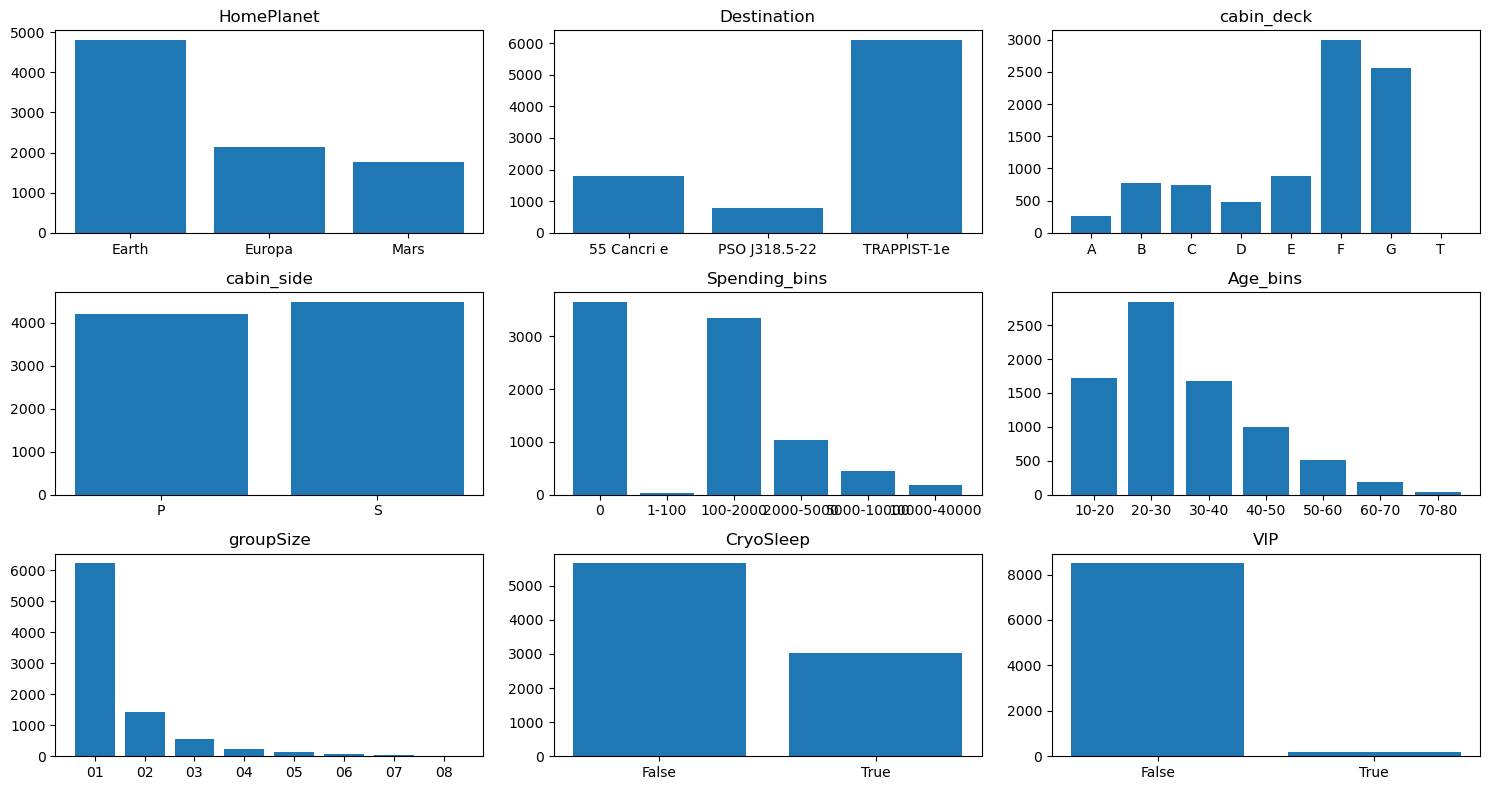

In [13]:
fig, ax = plt.subplots(3, 3, figsize=(15, 8))
ax = ax.flatten()

for idx, col in enumerate(columns_combined):
    bottom = np.zeros(len(xaxis_orders[idx]))
    transport_counts = data_train_explore[col].value_counts()
    transport_counts = transport_counts.reindex(xaxis_orders[idx])



    ax[idx].bar(transport_counts.index, transport_counts.values)

    ax[idx].set_xticks(np.arange(len(xaxis_orders[idx])), labels=xaxis_orders[idx])
    ax[idx].set_title(col)

plt.tight_layout()
plt.show()

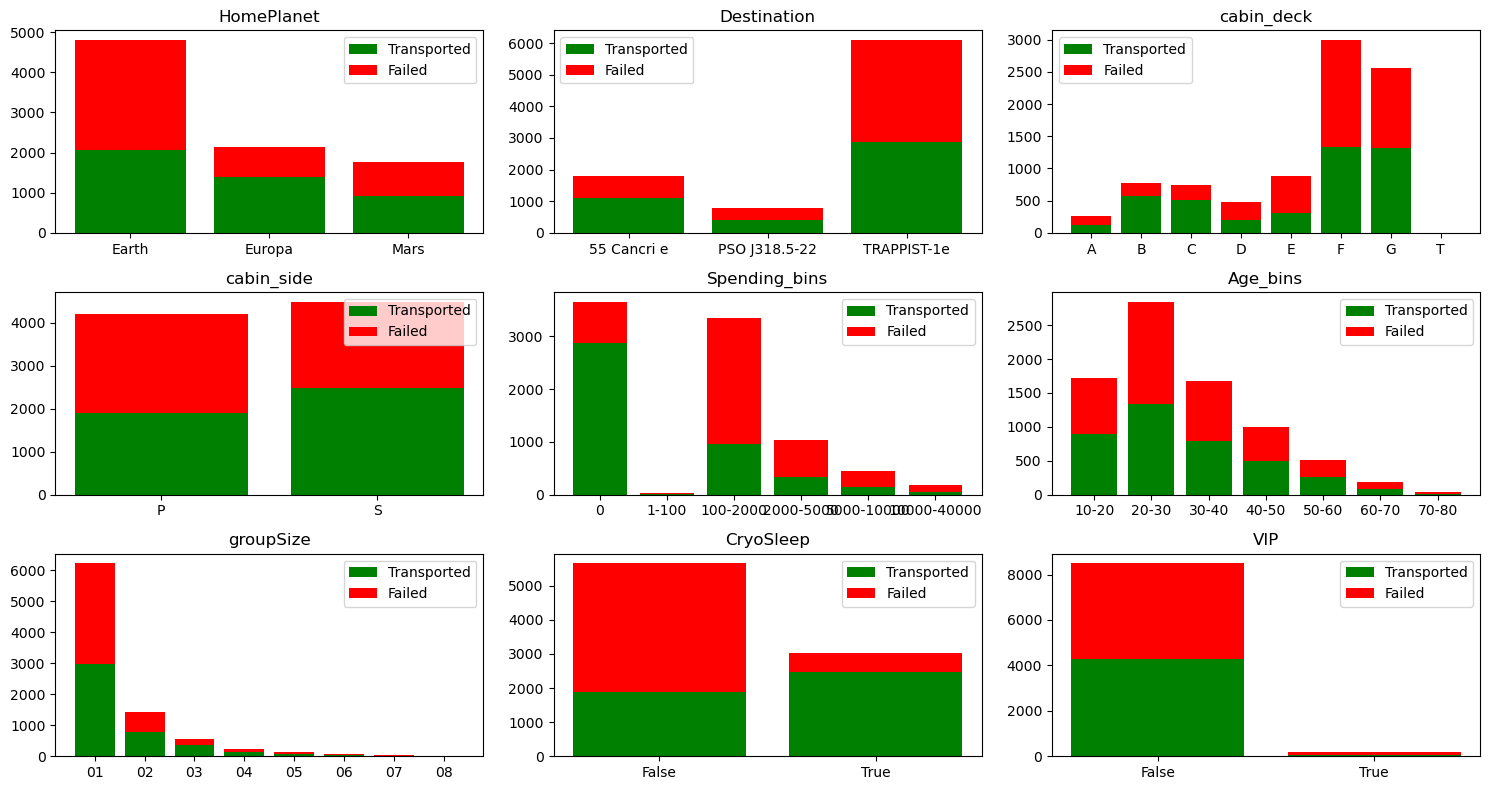

In [14]:
fig, ax = plt.subplots(3, 3, figsize=(15, 8))
ax = ax.flatten()


for idx, col in enumerate(columns_combined):
    bottom = np.zeros(len(xaxis_orders[idx]))
    transport_counts = data_train_explore[data_train_explore['Transported'] == True][col].value_counts()
    transport_counts = transport_counts.reindex(xaxis_orders[idx])

    fail_counts = data_train_explore[data_train_explore['Transported'] == False][col].value_counts()
    fail_counts = fail_counts.reindex(xaxis_orders[idx])


    ax[idx].bar(transport_counts.index, transport_counts.values, label='Transported', color='green', bottom=bottom)
    bottom += transport_counts.values
    ax[idx].bar(fail_counts.index, fail_counts.values, label='Failed', color='red', bottom=bottom)

    ax[idx].set_xticks(np.arange(len(xaxis_orders[idx])))
    ax[idx].set_xticklabels(xaxis_orders[idx])
    ax[idx].legend()
    ax[idx].set_title(col)

plt.tight_layout()
plt.show()

In [15]:
for c in columns_combined:
    print('Survival Correlation by:', c)
    print(data_train_explore[[c, "Transported"]].groupby(c, as_index=False, observed=False).mean())
    print('-'*10, '\n')


Survival Correlation by: HomePlanet
  HomePlanet Transported
0      Earth    0.427649
1     Europa    0.658846
2       Mars    0.523024
---------- 

Survival Correlation by: Destination
     Destination Transported
0    55 Cancri e        0.61
1  PSO J318.5-22    0.503769
2    TRAPPIST-1e    0.472199
---------- 

Survival Correlation by: cabin_deck
  cabin_deck Transported
0          A    0.496094
1          B    0.734275
2          C    0.680054
3          D    0.433054
4          E    0.357306
5          F    0.444036
6          G    0.516217
7          T         0.2
---------- 

Survival Correlation by: cabin_side
  cabin_side Transported
0          P     0.45126
1          S    0.552708
---------- 

Survival Correlation by: Spending_bins
  Spending_bins Transported
0             0    0.786047
1         1-100         0.3
2      100-2000    0.284901
3     2000-5000    0.329138
4    5000-10000    0.328947
5   10000-40000    0.303867
---------- 

Survival Correlation by: Age_bins
  Age

- users in CryoSleep had the highest chance of survival
- certain cabin_levels seem to be safer, e.g. B,C
- the majority of the lowest spending_bin survived 

**Open Questions:**
- are VIPs in CryoSleep more often? **No, actually less often**
- are the safe cabin_levels populated by VIPs? **No, VIPs are spread across most decks, but percentage wise there are more in the safe decks**
- are big spenders in CryoSleep more often? **No, interestingly only the lowest spending group (0-100) had people in CryoSleep, others never made use of it!**
    - more fine grained view: how about people that spent nothing? **only people that didn't spend anything went into cryosleep**

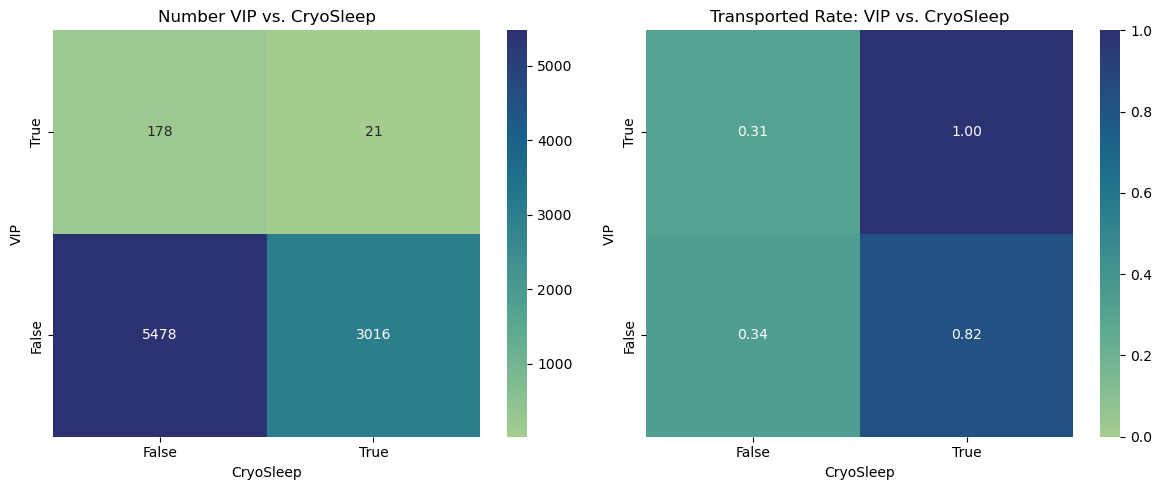

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax = ax.flatten()

cross_vip_deck = pd.crosstab(data_train_explore['VIP'], data_train_explore['CryoSleep']).reindex(index=[True,False])
sns.heatmap(cross_vip_deck, annot=True, fmt='d', ax=ax[0], cmap="crest")
ax[0].set_title('Number VIP vs. CryoSleep')
ax[0].set_ylabel('VIP')
ax[0].set_xlabel('CryoSleep')

pivot_vip_deck = data_train_explore.groupby(['VIP', 'CryoSleep'])['Transported'].mean().unstack().reindex(index=[True,False]).astype(float)
sns.heatmap(pivot_vip_deck, annot=True, fmt=".2f", ax=ax[1], cmap="crest", vmin=0, vmax=1)
ax[1].set_title('Transported Rate: VIP vs. CryoSleep')
ax[1].set_ylabel('VIP')
ax[1].set_xlabel('CryoSleep')

plt.tight_layout()
plt.show()

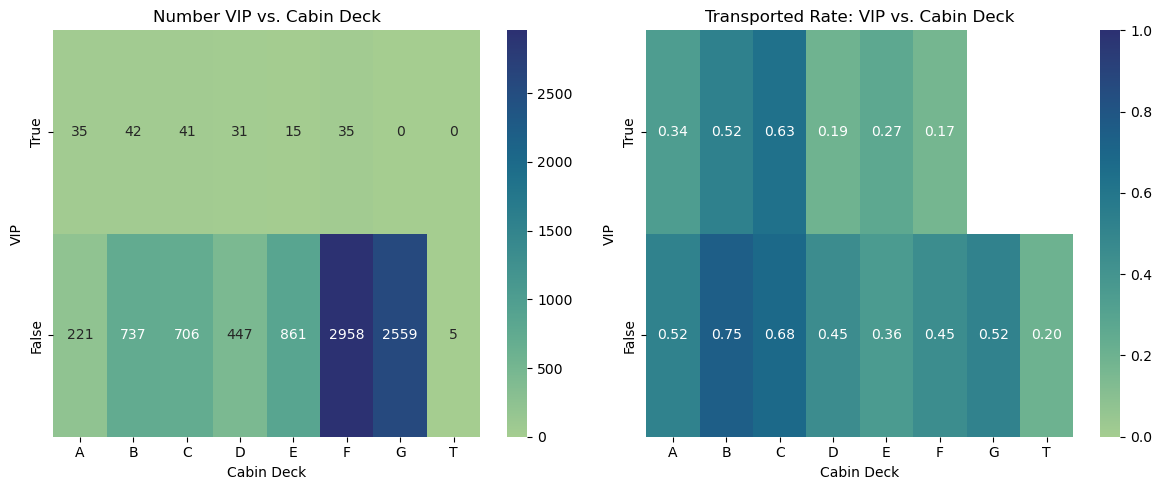

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax = ax.flatten()

cross_vip_deck = pd.crosstab(data_train_explore['VIP'], data_train_explore['cabin_deck']).reindex(index=[True,False])
sns.heatmap(cross_vip_deck, annot=True, fmt='d', ax=ax[0], cmap="crest")
ax[0].set_title('Number VIP vs. Cabin Deck')
ax[0].set_ylabel('VIP')
ax[0].set_xlabel('Cabin Deck')

pivot_vip_deck = data_train_explore.groupby(['VIP', 'cabin_deck'])['Transported'].mean().unstack().reindex(index=[True,False]).astype(float)
sns.heatmap(pivot_vip_deck, annot=True, fmt=".2f", ax=ax[1], cmap="crest", vmin=0, vmax=1)
ax[1].set_title('Transported Rate: VIP vs. Cabin Deck')
ax[1].set_ylabel('VIP')
ax[1].set_xlabel('Cabin Deck')

plt.tight_layout()
plt.show()

<Axes: xlabel='Spending_bins', ylabel='CryoSleep'>

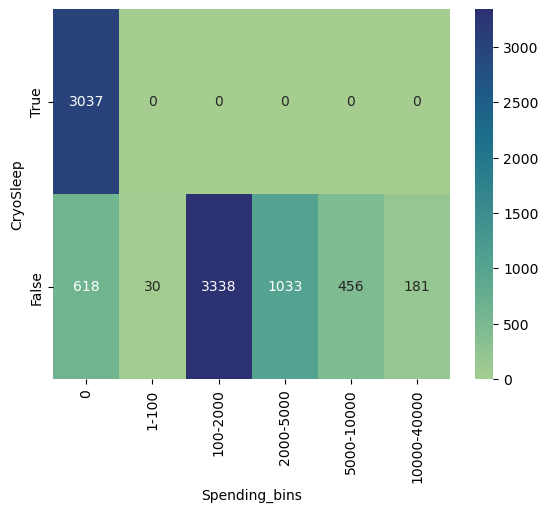

In [18]:
cross_vip_deck = pd.crosstab(data_train_explore['CryoSleep'], data_train_explore['Spending_bins']).reindex(index=[True,False])
sns.heatmap(cross_vip_deck, annot=True, fmt='d', cmap="crest")

In [19]:
data_train_explore[["Age_bins","Spending_bins"]].value_counts().unstack()

Spending_bins,0,1-100,100-2000,2000-5000,5000-10000,10000-40000
Age_bins,,,,,,
0-10,718.0,NaN,NaN,NaN,NaN,NaN
10-20,758.0,13.0,752.0,146.0,37.0,11.0
20-30,997.0,8.0,1280.0,352.0,157.0,53.0
30-40,580.0,5.0,632.0,267.0,134.0,62.0
40-50,338.0,2.0,390.0,159.0,76.0,29.0
50-60,191.0,2.0,200.0,67.0,35.0,22.0
60-70,62.0,NaN,69.0,37.0,14.0,1.0
70-80,11.0,NaN,15.0,5.0,3.0,3.0


In [20]:
data_train_explore[["Transported","Spending_bins"]].value_counts().unstack()

Spending_bins,0,1-100,100-2000,2000-5000,5000-10000,10000-40000
Transported,,,,,,
0.0,782,21,2387,693,306,126
1.0,2873,9,951,340,150,55


## Model Training
Baseline: 50% of people survive => by random guessing you achieve this value => anything model around this value is bad.

In [21]:
MLA = [
    #Ensemble Methods
    ensemble.AdaBoostClassifier(),
    ensemble.BaggingClassifier(),
    ensemble.ExtraTreesClassifier(),
    ensemble.GradientBoostingClassifier(),
    ensemble.RandomForestClassifier(),

    #GLM
    linear_model.PassiveAggressiveClassifier(),
    linear_model.RidgeClassifierCV(),
    linear_model.SGDClassifier(),
    linear_model.Perceptron(),
    
    #Navies Bayes
    naive_bayes.BernoulliNB(),
    naive_bayes.GaussianNB(),
    
    #Nearest Neighbor
    neighbors.KNeighborsClassifier(),
    
    #SVM
    svm.SVC(probability=True),

    
    #Trees    
    tree.DecisionTreeClassifier(),
    tree.ExtraTreeClassifier(),
    
    XGBClassifier()
    ]


#create table to compare MLA metrics
MLA_columns = ['MLA Name', 'MLA Parameters','MLA Train Accuracy Mean', 'MLA Test Accuracy Mean', 'MLA Time']
MLA_compare = pd.DataFrame(columns = MLA_columns)

fitted_models = {}

row_index = 0
for alg in MLA:

    MLA_name = alg.__class__.__name__
    print('-' * 50)
    print(MLA_name)
    MLA_compare.loc[row_index, 'MLA Name'] = MLA_name
    MLA_compare.loc[row_index, 'MLA Parameters'] = str(alg.get_params())

    cv_results = model_selection.cross_validate(alg, data_xtrain_dummies, data_ytrain_dummies, cv=5, return_train_score=True, n_jobs=4, scoring='accuracy')

    MLA_compare.loc[row_index, 'MLA Time'] = cv_results['fit_time'].mean()
    MLA_compare.loc[row_index, 'MLA Train Accuracy Mean'] = cv_results['train_score'].mean()
    MLA_compare.loc[row_index, 'MLA Test Accuracy Mean'] = cv_results['test_score'].mean()   

    #save MLA predictions - see section 6 for usage
    alg.fit(data_xtrain_dummies, data_ytrain_dummies)
    fitted_models[MLA_name] = alg
    row_index+=1

    
#print and sort table: https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.sort_values.html
MLA_compare.sort_values(by = ['MLA Test Accuracy Mean'], ascending = False, inplace = True)
MLA_compare

--------------------------------------------------
AdaBoostClassifier


--------------------------------------------------
BaggingClassifier
--------------------------------------------------
ExtraTreesClassifier
--------------------------------------------------
GradientBoostingClassifier
--------------------------------------------------
RandomForestClassifier
--------------------------------------------------
PassiveAggressiveClassifier
--------------------------------------------------
RidgeClassifierCV
--------------------------------------------------
SGDClassifier
--------------------------------------------------
Perceptron
--------------------------------------------------
BernoulliNB
--------------------------------------------------
GaussianNB
--------------------------------------------------
KNeighborsClassifier
--------------------------------------------------
SVC
--------------------------------------------------
DecisionTreeClassifier
--------------------------------------------------
ExtraTreeClassifier
-----------------------------------

,MLA Name,MLA Parameters,MLA Train Accuracy Mean,MLA Test Accuracy Mean,MLA Time
3,GradientBoostingClassifier,"{'ccp_alpha': 0.0, 'criterion': 'friedman_mse'...",0.815973,0.796621,1.380508
15,XGBClassifier,"{'objective': 'binary:logistic', 'base_score':...",0.88416,0.789143,0.328734
12,SVC,"{'C': 1.0, 'break_ties': False, 'cache_size': ...",0.789687,0.786038,14.253434
4,RandomForestClassifier,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",0.928678,0.78339,0.941133
0,AdaBoostClassifier,"{'algorithm': 'deprecated', 'estimator': None,...",0.783561,0.780055,0.335277
1,BaggingClassifier,"{'bootstrap': True, 'bootstrap_features': Fals...",0.916974,0.777983,0.240215
6,RidgeClassifierCV,"{'alphas': (0.1, 1.0, 10.0), 'class_weight': N...",0.777867,0.774878,0.10916
2,ExtraTreesClassifier,"{'bootstrap': False, 'ccp_alpha': 0.0, 'class_...",0.928707,0.768091,0.932217
7,SGDClassifier,"{'alpha': 0.0001, 'average': False, 'class_wei...",0.768952,0.764181,0.100359
10,GaussianNB,"{'priors': None, 'var_smoothing': 1e-09}",0.770447,0.761996,0.016279


Text(0, 0.5, 'Algorithm')

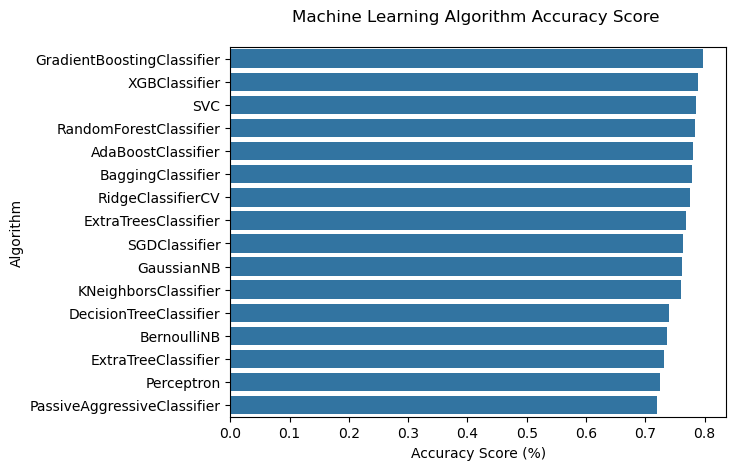

In [22]:
sns.barplot(x='MLA Test Accuracy Mean', y = 'MLA Name', data = MLA_compare)
plt.title('Machine Learning Algorithm Accuracy Score \n')
plt.xlabel('Accuracy Score (%)')
plt.ylabel('Algorithm')

#### Baseline Submission

In [23]:
submission = pd.DataFrame()
svc_model = fitted_models.get("GradientBoostingClassifier")
submission["PassengerId"] = data_test["PassengerId"]
submission["Transported"] = svc_model.predict(data_xtest_dummies).astype(bool)

submission.to_csv("./results/v1_baseline_gradboost_submission.csv", index=False)
# 0.80149

## Parameter Optimization

In [24]:
optimize_MLA = [
    ensemble.AdaBoostClassifier(),
    linear_model.SGDClassifier(),
    svm.SVC(probability=True),
    XGBClassifier(),
    ensemble.RandomForestClassifier(),
    ]


param_grid_svc = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'max_iter': [10000]
}
param_grid_sgd = {
    'loss': ['hinge', 'log_loss', 'modified_huber'],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [1e-4, 1e-3, 1e-2],
    'learning_rate': ['optimal', 'invscaling', 'adaptive'],
    'eta0': [0.01, 0.1, 1],
    'fit_intercept': [True, False]
}
param_grid_ada = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 1.0],
}
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.3],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 0.1, 0],
    'random_state': [42],
}


param_grid_rf = {
    'n_estimators': [50, 150, 300],
    'max_leaf_nodes': [50, 100, 200],
    'max_depth': [None, 10, 25],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [ 2, 4],
}

optimize_MLA_grid = [
    param_grid_ada, param_grid_sgd, param_grid_svc, param_grid_xgb, param_grid_rf
]


#create table to compare MLA metrics
optimize_MLA_columns = ['MLA Name', 'MLA Parameters','MLA Train Accuracy Mean', 'MLA Train Improvement','MLA Test Accuracy Mean', 'MLA Test Improvement', 'MLA Time']
optimize_MLA_compare = pd.DataFrame(columns = optimize_MLA_columns)


optimize_fitted_models = {}
row_index = 0

for idx, alg in enumerate(optimize_MLA):
    optimize_MLA_name = alg.__class__.__name__
    optimize_MLA_compare.loc[row_index, 'MLA Name'] = optimize_MLA_name
    print('-' * 50)
    print(optimize_MLA_name)

    if optimize_MLA_name == "XGBClassifier":
        gridSearch_result = RandomizedSearchCV(alg, param_distributions=optimize_MLA_grid[idx], cv=5, n_iter=100 ,verbose=True, n_jobs=7, return_train_score=True, scoring='accuracy')
    else:
        gridSearch_result = GridSearchCV(alg, param_grid=optimize_MLA_grid[idx], cv=5, verbose=True, n_jobs=7, return_train_score=True, scoring='accuracy')
    gridSearch_result.fit(data_xtrain_dummies, data_ytrain_dummies)

    row_index_compare = MLA_compare[MLA_compare['MLA Name'] == alg.__class__.__name__].index[0]

    optimize_MLA_compare.loc[row_index, 'MLA Parameters'] = str(gridSearch_result.best_params_)
    optimize_MLA_compare.loc[row_index, 'MLA Time'] = gridSearch_result.cv_results_['mean_fit_time'][gridSearch_result.best_index_]
    
    mean_train_score = gridSearch_result.cv_results_['mean_train_score'][gridSearch_result.best_index_]
    optimize_MLA_compare.loc[row_index, 'MLA Train Accuracy Mean'] = mean_train_score
    optimize_MLA_compare.loc[row_index, 'MLA Train Improvement'] = mean_train_score - MLA_compare.iloc[row_index_compare, 2]

    mean_test_score = gridSearch_result.cv_results_['mean_test_score'][gridSearch_result.best_index_] 
    optimize_MLA_compare.loc[row_index, 'MLA Test Accuracy Mean'] = mean_test_score
    optimize_MLA_compare.loc[row_index, 'MLA Test Improvement'] = mean_test_score - MLA_compare.iloc[row_index_compare, 3]

    optimize_fitted_models[optimize_MLA_name] = gridSearch_result.best_estimator_
    row_index+=1


optimize_MLA_compare.sort_values(by = ['MLA Test Accuracy Mean'], ascending = False, inplace = True)
optimize_MLA_compare




--------------------------------------------------
AdaBoostClassifier
Fitting 5 folds for each of 12 candidates, totalling 60 fits
--------------------------------------------------
SGDClassifier
Fitting 5 folds for each of 486 candidates, totalling 2430 fits


/home/kiwiii/anaconda3/envs/kaggle/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


--------------------------------------------------
SVC
Fitting 5 folds for each of 9 candidates, totalling 45 fits


/home/kiwiii/anaconda3/envs/kaggle/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/kiwiii/anaconda3/envs/kaggle/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/kiwiii/anaconda3/envs/kaggle/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/kiwiii/anaconda3/envs/kaggle/lib/python3.13/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/home/kiwiii/anaconda3/envs/kaggle/l

--------------------------------------------------
XGBClassifier
Fitting 5 folds for each of 100 candidates, totalling 500 fits
--------------------------------------------------
RandomForestClassifier
Fitting 5 folds for each of 108 candidates, totalling 540 fits


,MLA Name,MLA Parameters,MLA Train Accuracy Mean,MLA Train Improvement,MLA Test Accuracy Mean,MLA Test Improvement,MLA Time
3,XGBClassifier,"{'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha...",0.826441,0.11124,0.801912,0.082822,0.324566
4,RandomForestClassifier,"{'max_depth': 10, 'max_leaf_nodes': 200, 'min_...",0.831991,0.04843,0.797771,0.017716,0.545155
2,SVC,"{'C': 10, 'kernel': 'rbf', 'max_iter': 10000}",0.794116,0.057086,0.789144,0.052111,37.439241
0,AdaBoostClassifier,"{'learning_rate': 1.0, 'n_estimators': 200}",0.788796,-0.027177,0.785807,-0.010814,2.597153
1,SGDClassifier,"{'alpha': 0.01, 'eta0': 0.1, 'fit_intercept': ...",0.787473,-0.141234,0.785693,0.017602,0.560872


#### Optimize submission

In [25]:
submission = pd.DataFrame()
optimized_xgb_model = optimize_fitted_models.get("XGBClassifier")
submission["PassengerId"] = data_test["PassengerId"]
submission["Transported"] = optimized_xgb_model.predict(data_xtest_dummies).astype(bool)

submission.to_csv("./results/v1_optimized_xgb_submission.csv", index=False)

# 0.80032

In [26]:
voters = [
    ('ada', optimize_fitted_models['AdaBoostClassifier']),
    ('sgd', optimize_fitted_models['SGDClassifier']),
    ('svc', optimize_fitted_models['SVC']),
    ('xgb', optimize_fitted_models['XGBClassifier']),
    ('rfc', optimize_fitted_models['RandomForestClassifier'])
]

voting_hard = VotingClassifier(estimators = voters, voting = 'hard')
voting_soft = VotingClassifier(estimators = voters, voting = 'soft')

cv_results_hard = model_selection.cross_validate(voting_hard, data_xtrain_dummies, data_ytrain_dummies, cv=10, return_train_score=True, n_jobs=7)
cv_results_soft = model_selection.cross_validate(voting_soft, data_xtrain_dummies, data_ytrain_dummies, cv=10, return_train_score=True, n_jobs=7)
 
print('voting_clf_hard train: ', cv_results_hard['train_score'].mean())
print('voting_clf_hard test:',cv_results_hard['test_score'].mean())

print('voting_clf_soft train: ', cv_results_soft['train_score'].mean())
print('voting_clf_soft test:',cv_results_soft['test_score'].mean())




voting_clf_hard train:  0.8154199300107935
voting_clf_hard test: 0.7994988294115313
voting_clf_soft train:  0.8086967009999093
voting_clf_soft test: 0.7953566657407775


In [27]:
submission = pd.DataFrame()
voting_hard.fit(data_xtrain_dummies, data_ytrain_dummies)
submission["PassengerId"] = data_test["PassengerId"]
submission["Transported"] = voting_hard.predict(data_xtest_dummies).astype(bool)

submission.to_csv("./results/v1_ensemble_submission.csv", index=False)
# 0.80079